In [1]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = img.astype(np.float32) / 255.0
    return img

def GetSobelFeatures(img):
    # Compute x and y gradients using Sobel
    Gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

    # Gradient magnitude and orientation
    M = np.sqrt(Gx ** 2 + Gy ** 2)
    Theta = np.arctan2(Gy, Gx)  # in radians

    return Gx, Gy, M, Theta

def run_canny_batch(img, thresholds):
    edges = []
    for low, high in thresholds:
        edge = cv2.Canny(img, low, high)
        edges.append(edge)
    return edges

def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()


    plt.tight_layout()
    plt.show()

#This function is made by ChatGPT
def rotate_image(image, angle):
    height, width = image.shape[:2]
    center = (width/2, height/2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Scale to 0-255 for warpAffine
    rotated = cv2.warpAffine((image*255).astype(np.uint8), M, (width, height))

    # Convert back to 0-1 float if needed
    rotated = rotated.astype(np.float32) / 255.0

    return rotated

def normalize_for_display(result):
    norm = (result - np.min(result)) / (np.max(result) - np.min(result))
    return norm


(1024, 9)
(961, 36)
(961, 36)


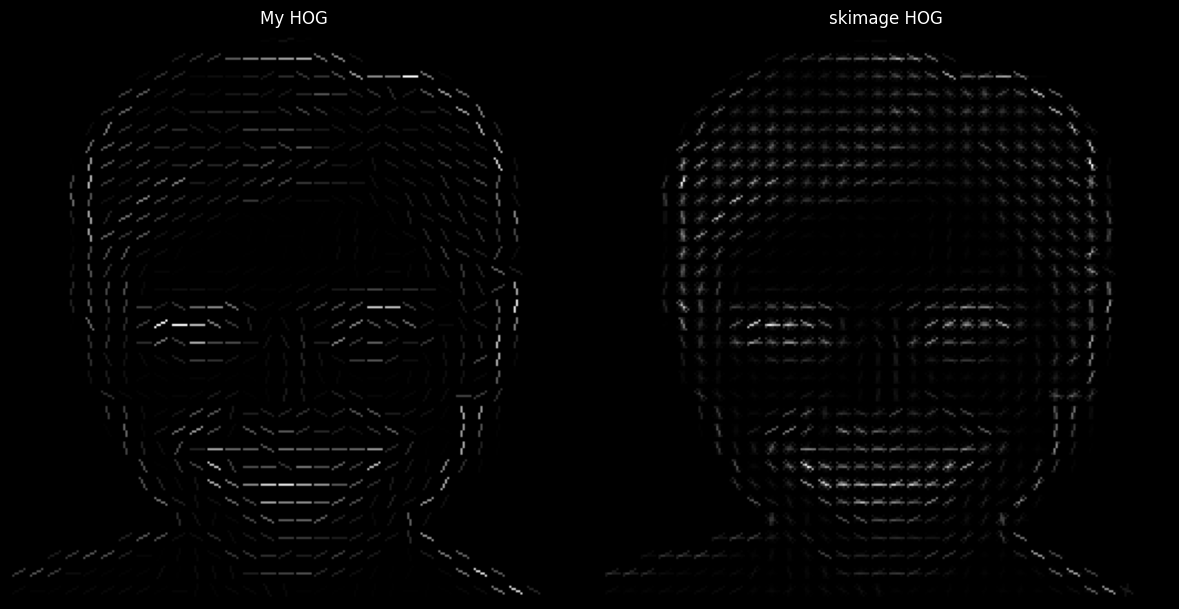

In [2]:
#1.
img = LoadImage('smile-beauty-portrait-woman-studio-with-skincare-natural-face-routine-wellness-happy-cosmetic-female-person-from-canada-with-facial-dermatology-treatment-by-white-background_590464-305435.jpg')
Gx, Gy, M, Theta = GetSobelFeatures(img)

def divide_to_cells(img, pixels = 8):
    h,w = img.shape[:2]
    cells = []
    for y in range(0, h, pixels):
        for x in range(0, w, pixels):
            cell = img[y:y+pixels, x:x+pixels]
            cells.append(cell)
    return cells

def create_histogram_of_cells(M, Theta, pixels = 8):
    h,w = M.shape
    hist_list = []

    for y in range(0, h, pixels):
        for x in range(0, w, pixels):
            M_cell = M[y:y+pixels, x:x+pixels].ravel() # ravel used to make it easier to make histogram
            Theta_cell = Theta[y:y+pixels, x:x+pixels].ravel()

            Theta_cell = np.degrees(Theta_cell) % 180

            hist, _ = np.histogram(Theta_cell, bins=9, range=(0,180), weights=M_cell )
            hist_list.append(hist)

    return np.array(hist_list)



cells = divide_to_cells(img)
x = create_histogram_of_cells(M, Theta)


print(x.shape)
def create_blocks(hog_list):
    blocks = []
    hog_list = hog_list.reshape(32,32,9)
    cells_y, cells_x, bins = hog_list.shape

    for y in range(cells_y-1):
        for x in range(cells_x-1):
            block = hog_list[y:y+2, x:x+2]
            block_vector = block.ravel()

            blocks.append(block_vector)
    return np.array(blocks)

xx = create_blocks(x)
print(xx.shape)

def normalize_histogram(blocks):
    blocks_norm = []
    for block in blocks:
        norm = np.linalg.norm(block)
        block = block / (norm + 1e-6)
        blocks_norm.append(block)
    return np.array(blocks_norm)

xxx = normalize_histogram(xx)

print(xxx.shape)


def visualize_hog(cells_histogram, cell_size=8, scale=3, threshold=0.01):
    num_cells, bins = cells_histogram.shape
    h_cells = int(np.sqrt(num_cells))
    w_cells = h_cells

    canvas = np.zeros((h_cells * cell_size, w_cells * cell_size), np.uint8)
    cells_histogram = cells_histogram.reshape(h_cells, w_cells, bins)

    bin_width = 180 / bins

    # normalize globally for consistent brightness
    max_val = cells_histogram.max() + 1e-6

    for y in range(h_cells):
        for x in range(w_cells):
            hist = cells_histogram[y, x]

            strength = hist.max()  # dominant orientation strength

            if strength < threshold:
                continue

            dominant_bin = np.argmax(hist)

            angle = dominant_bin * bin_width + bin_width / 2
            theta = np.deg2rad(angle)

            cx = x * cell_size + cell_size // 2
            cy = y * cell_size + cell_size // 2


            half = scale

            # Compute line perpendicular to gradient
            dx = half * np.cos(theta + np.pi/2)
            dy = half * np.sin(theta + np.pi/2)



            # brightness encodes magnitude
            intensity = int(255 * (strength / max_val))

            pt1 = (int(cx - dx), int(cy - dy))
            pt2 = (int(cx + dx), int(cy + dy))

            cv2.line(canvas, pt1, pt2, intensity, 1)

    return canvas


canvas = visualize_hog(x)


img_gray = LoadImage('smile-beauty-portrait-woman-studio-with-skincare-natural-face-routine-wellness-happy-cosmetic-female-person-from-canada-with-facial-dermatology-treatment-by-white-background_590464-305435.jpg')

hog_features, hog_image = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2',
    visualize=True,
    feature_vector=True
)

#hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(canvas, cmap='gray')
ax1.set_title('My HOG')
ax1.axis('off')

ax2.imshow(hog_image, cmap='gray')
ax2.set_title('skimage HOG')
ax2.axis('off')

plt.tight_layout()
plt.show()


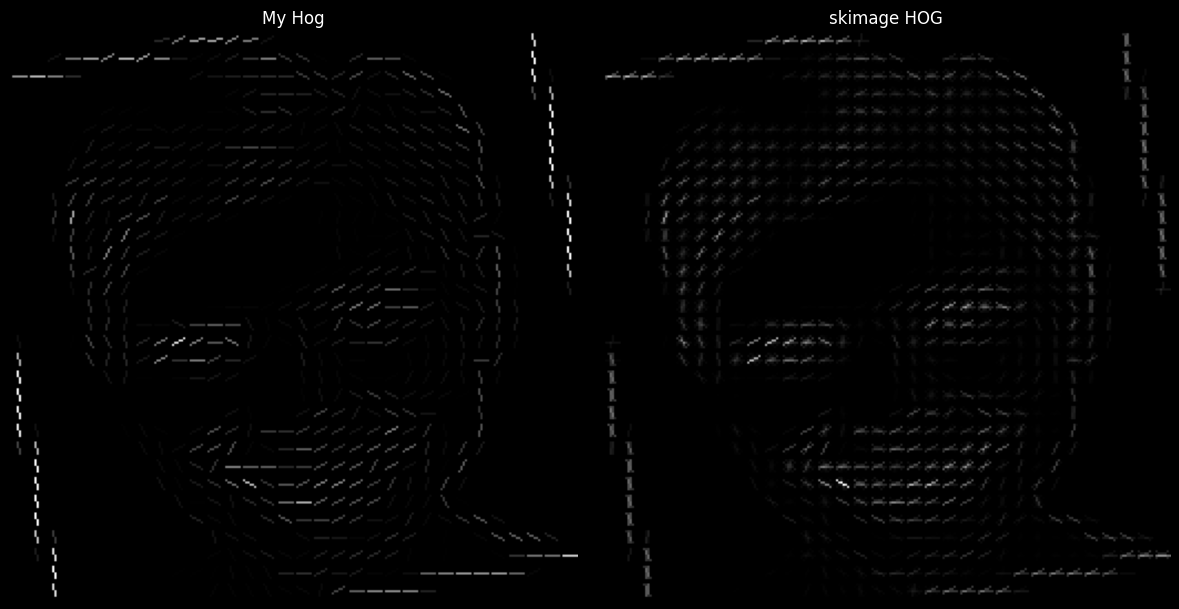

In [3]:
img1 = LoadImage('smile-beauty-portrait-woman-studio-with-skincare-natural-face-routine-wellness-happy-cosmetic-female-person-from-canada-with-facial-dermatology-treatment-by-white-background_590464-305435.jpg')
img1 = rotate_image(img1, 10)
img1 = (img1*255 + 50).clip(0,255).astype(np.float32) / 255.0
Gx, Gy, M, Theta = GetSobelFeatures(img1)
x = create_histogram_of_cells(M, Theta)
hog_image = visualize_hog(x)


img_gray = LoadImage('smile-beauty-portrait-woman-studio-with-skincare-natural-face-routine-wellness-happy-cosmetic-female-person-from-canada-with-facial-dermatology-treatment-by-white-background_590464-305435.jpg')

img_gray = rotate_image(img_gray, 10)
img_gray = (img_gray*255+50).clip(0, 255).astype(np.float32) / 255

hog_features, img_gray_hog = hog(
    img_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm='L2',
    visualize=True,
    feature_vector=True
)

hog_image_rescaled = exposure.rescale_intensity(img_gray_hog, in_range=(0, 10))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(hog_image, cmap='gray')
ax1.set_title('My Hog')
ax1.axis('off')

ax2.imshow(hog_image_rescaled, cmap='gray')
ax2.set_title('skimage HOG')
ax2.axis('off')

plt.tight_layout()
plt.show()
